<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Barra_Lateral_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Card Barra Lateral

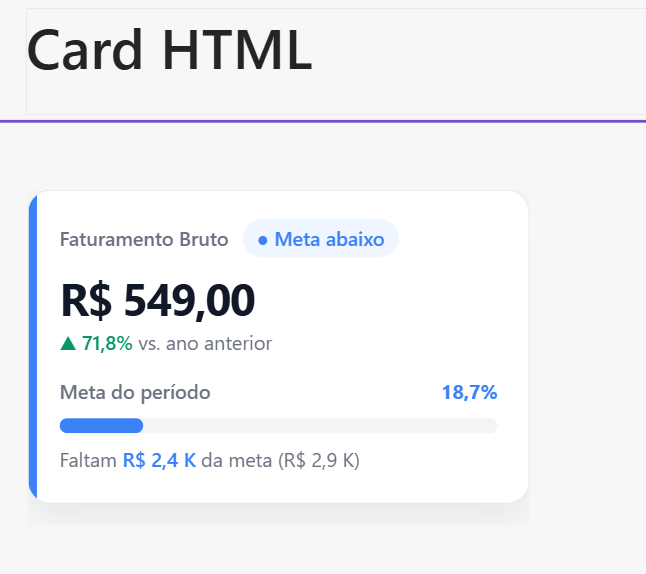

In [ ]:
HTML card-barra-lateral =
//======================================================
//==================== VALORES ========================
VAR Fat         = [faturamento_bruto]
VAR Meta        = [faturamento_bruto_meta]
VAR YoY         = [faturamento_bruto YoY %]
VAR Ating       = [%atingimento_meta]

//======================================================

-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║        Card executivo com status pill + falta para meta         ║
-- ╚══════════════════════════════════════════════════════════════════╝

-- ──────── 🏷️ TEXTOS ────────
VAR varTitulo           = "Faturamento Bruto"
VAR varLabelMeta        = "Meta do período"
VAR varComparativo      = "vs. ano anterior"
VAR TextoMetaOk         = "Meta atingida"
VAR TextoMetaAbaixo     = "Meta abaixo"
VAR TextoFaltaMeta      = "Faltam"
VAR TextoExcedeuMeta    = "Superou em"

-- ──────── 🎨 CORES ────────
VAR CorFundo            = "#FFFFFF"
VAR CorBorda            = "#E5E7EB"
VAR CorTitulo           = "#6B7280"
VAR CorValor            = "#111827"
VAR CorTextoSuave       = "#6B7280"
VAR CorBarraFundo       = "#F3F4F6"
VAR CorPosi             = "#059669"
VAR CorNega             = "#DC2626"
VAR CorStatusOk         = "#059669"
VAR CorStatusAbaixo     = "#3B82F6"
VAR CorPillOk           = "#ECFDF5"
VAR CorPillAbaixo       = "#EFF6FF"
VAR CorDetalheOk        = "#059669"
VAR CorDetalheAbaixo    = "#3B82F6"

-- ──────── 🌈 DETALHE COLORIDO ────────
VAR PosicaoDetalhe      = "esquerda"
VAR LarguraDetalhe      = "6px"

-- ──────── 🎨 ÍCONE ────────
VAR PosicaoIcone        = "nenhum"
VAR IconePath = "M12 22s8-4 8-10V5l-8-3-8 3v7c0 6 8 10 8 10zM9 12l2 2 4-4"
VAR TamanhoCaixaIcone  = "34px"
VAR RaioCaixaIcone     = "10px"
VAR StrokeIcone        = "1.8"

-- ──────── 📐 LAYOUT ────────
VAR RaioBorda           = "16px"
VAR Padding             = "20px 22px"
VAR SombraCard          = "0 10px 28px rgba(17,24,39,.07)"

-- ──────── 📏 TIPOGRAFIA ────────
VAR FonteGlobal         = "'Segoe UI', system-ui, sans-serif"
VAR TamanhoTitulo       = "14px"
VAR TamanhoValor        = "32px"
VAR TamanhoVariacao     = "14px"
VAR TamanhoMeta         = "14px"
VAR TamanhoPill         = "14px"
VAR TamanhoInsight      = "14px"

-- ──────── 🎯 BARRA DE META ────────
VAR AlturaBarraPx       = "11"
VAR RaioBarraPx         = "999"
VAR AnimarBarra         = TRUE()
VAR DuracaoAnimacao     = "1.4s"

-- ──────── 🔢 FORMATAÇÃO ────────
VAR AbreviarValores     = TRUE()
VAR CasasDecimais       = "1"


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ╚══════════════════════════════════════════════════════════════════╝

VAR Posi        = YoY >= 0
VAR MetaOk      = Ating >= 1
VAR FaltaMeta   = Meta - Fat
VAR DeltaMeta   = ABS(FaltaMeta)
VAR _fmt        = "#,##0." & REPT("0", VALUE(CasasDecimais))
VAR FatAbs      = ABS(Fat)
VAR MetaAbs     = ABS(Meta)
VAR DeltaAbs    = ABS(DeltaMeta)
VAR PctBarraNum = MIN(1, MAX(0, Ating)) * 100
VAR PctBarra    = FORMAT(PctBarraNum, "0") & "%"

VAR FatFmt = IF(AbreviarValores, SWITCH(TRUE(), FatAbs >= 1000000000, "R$ " & FORMAT(Fat/1000000000, _fmt) & " B", FatAbs >= 1000000, "R$ " & FORMAT(Fat/1000000, _fmt) & " M", FatAbs >= 1000, "R$ " & FORMAT(Fat/1000, _fmt) & " K", "R$ " & FORMAT(Fat, "#,##0.00")), "R$ " & FORMAT(Fat, "#,##0.00"))
VAR MetaFmt = IF(AbreviarValores, SWITCH(TRUE(), MetaAbs >= 1000000000, "R$ " & FORMAT(Meta/1000000000, _fmt) & " B", MetaAbs >= 1000000, "R$ " & FORMAT(Meta/1000000, _fmt) & " M", MetaAbs >= 1000, "R$ " & FORMAT(Meta/1000, _fmt) & " K", "R$ " & FORMAT(Meta, "#,##0.00")), "R$ " & FORMAT(Meta, "#,##0.00"))
VAR DeltaMetaFmt = IF(AbreviarValores, SWITCH(TRUE(), DeltaAbs >= 1000000000, "R$ " & FORMAT(DeltaMeta/1000000000, _fmt) & " B", DeltaAbs >= 1000000, "R$ " & FORMAT(DeltaMeta/1000000, _fmt) & " M", DeltaAbs >= 1000, "R$ " & FORMAT(DeltaMeta/1000, _fmt) & " K", "R$ " & FORMAT(DeltaMeta, "#,##0.00")), "R$ " & FORMAT(DeltaMeta, "#,##0.00"))
VAR YoYFmt        = FORMAT(ABS(YoY), "0.0%")
VAR AtingFmt      = FORMAT(Ating, "0.0%")
VAR CorStatusYoY  = IF(Posi, CorPosi, CorNega)
VAR CorStatusMeta = IF(MetaOk, CorStatusOk, CorStatusAbaixo)
VAR CorPill       = IF(MetaOk, CorPillOk, CorPillAbaixo)
VAR CorDetalhe    = IF(MetaOk, CorDetalheOk, CorDetalheAbaixo)
VAR TextoStatus   = IF(MetaOk, TextoMetaOk, TextoMetaAbaixo)
VAR TextoInsight  = IF(MetaOk, TextoExcedeuMeta, TextoFaltaMeta)
VAR Seta          = IF(Posi, "▲", "▼")

VAR DetalheCss = SWITCH(TRUE(), PosicaoDetalhe = "direita", ".card:before{content:'';position:absolute;right:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}", PosicaoDetalhe = "esquerda", ".card:before{content:'';position:absolute;left:0;top:0;bottom:0;width:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}", PosicaoDetalhe = "baixo", ".card:before{content:'';position:absolute;left:0;right:0;bottom:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}", PosicaoDetalhe = "nenhuma", ".card:before{content:none;}", ".card:before{content:'';position:absolute;left:0;right:0;top:0;height:" & LarguraDetalhe & ";background:" & CorDetalhe & ";}")

VAR Icone = "<svg width='19' height='19' viewBox='0 0 24 24' fill='none' stroke='" & CorStatusMeta & "' stroke-width='" & StrokeIcone & "' stroke-linecap='round' stroke-linejoin='round'><path d='" & IconePath & "'/></svg>"
VAR IconeHtml = "<div class='icone-wrap'>" & Icone & "</div>"
VAR IconeEsquerda = IF(PosicaoIcone = "esquerda", IconeHtml, "")
VAR IconeDireita  = IF(PosicaoIcone = "direita",  IconeHtml, "")
VAR HeaderClasse  = IF(PosicaoIcone = "nenhum", "header-line sem-icone", "header-line")

VAR AnimacaoBarraCss = IF(AnimarBarra, "animation:progressAnimationExecutivo " & DuracaoAnimacao & " cubic-bezier(.22,.61,.36,1) both;", "")
VAR KeyframesBarraCss = IF(AnimarBarra, "@keyframes progressAnimationExecutivo{from{width:0%;}to{width:" & PctBarra & ";}}", "")


RETURN
"<!DOCTYPE html><html lang='pt-BR'><head><meta charset='UTF-8'>
<style>
  html,body{margin:0;padding:0;width:100%;height:100%;font-family:" & FonteGlobal & ";background:transparent;display:flex;align-items:center;justify-content:center;}
  .card{position:relative;overflow:hidden;background:" & CorFundo & ";border:1px solid " & CorBorda & ";border-radius:" & RaioBorda & ";padding:" & Padding & ";width:100%;height:100%;box-sizing:border-box;display:flex;flex-direction:column;justify-content:space-between;box-shadow:" & SombraCard & ";}
  " & DetalheCss & "
  .header-line{display:flex;align-items:center;justify-content:space-between;gap:10px;min-width:0;}
  .header-line.sem-icone{display:block;}
  .title-wrap{display:flex;align-items:center;gap:10px;min-width:0;flex:1;}
  .title{font-size:" & TamanhoTitulo & ";font-weight:600;color:" & CorTitulo & ";white-space:nowrap;}
  .pill{display:inline-flex;align-items:center;gap:5px;background:" & CorPill & ";color:" & CorStatusMeta & ";border-radius:999px;padding:3px 10px;font-size:" & TamanhoPill & ";font-weight:600;white-space:nowrap;flex-shrink:0;}
  .icone-wrap{width:" & TamanhoCaixaIcone & ";height:" & TamanhoCaixaIcone & ";min-width:" & TamanhoCaixaIcone & ";border-radius:" & RaioCaixaIcone & ";background:" & CorPill & ";display:flex;align-items:center;justify-content:center;flex-shrink:0;}
  .value{font-size:" & TamanhoValor & ";font-weight:750;color:" & CorValor & ";letter-spacing:-1.2px;line-height:1;white-space:nowrap;margin-top:12px;}
  .yoy{font-size:" & TamanhoVariacao & ";font-weight:600;color:" & CorStatusYoY & ";margin-top:6px;white-space:nowrap;}
  .comp{color:" & CorTextoSuave & ";font-weight:400;}
  .meta-row{display:flex;justify-content:space-between;align-items:center;margin-top:14px;gap:10px;}
  .meta-label{font-size:" & TamanhoMeta & ";color:" & CorTitulo & ";font-weight:500;}
  .meta-pct{font-size:" & TamanhoMeta & ";font-weight:700;color:" & CorStatusMeta & ";}
  .bar-bg{background:" & CorBarraFundo & ";border-radius:" & RaioBarraPx & "px;height:" & AlturaBarraPx & "px;width:100%;margin-top:8px;overflow:hidden;}
  .bar-fill{height:100%;border-radius:" & RaioBarraPx & "px;background:" & CorStatusMeta & ";width:" & PctBarra & ";" & AnimacaoBarraCss & "}
  " & KeyframesBarraCss & "
  .insight{font-size:" & TamanhoInsight & ";color:" & CorTextoSuave & ";margin-top:8px;white-space:nowrap;}
  .insight-val{color:" & CorStatusMeta & ";font-weight:600;}
</style></head><body>
<div class='card'>
  <div class='" & HeaderClasse & "'>
    " & IconeEsquerda & "
    <div class='title-wrap'>
      <span class='title'>" & varTitulo & "</span>
      <span class='pill'>● " & TextoStatus & "</span>
    </div>
    " & IconeDireita & "
  </div>
  <div class='value'>" & FatFmt & "</div>
  <div class='yoy'>" & Seta & " " & YoYFmt & " <span class='comp'>" & varComparativo & "</span></div>
  <div>
    <div class='meta-row'>
      <span class='meta-label'>" & varLabelMeta & "</span>
      <span class='meta-pct'>" & AtingFmt & "</span>
    </div>
    <div class='bar-bg'><div class='bar-fill'></div></div>
    <div class='insight'>" & TextoInsight & " <span class='insight-val'>" & DeltaMetaFmt & "</span> da meta (" & MetaFmt & ")</div>
  </div>
</div>
</body></html>"
